In this work I used data and project @nasimetemadi

## Fraud Detection in Financial Transactions
### Problem
Identifying fraudulent transactions is a crucial yet complex task within contemporary financial systems. Traditional supervised machine learning methods depend on datasets where fraudulent and legitimate transactions are distinctly labeled. However, in practical applications, such labeled data is often scarce, significantly imbalanced, or not available at all. This situation calls for unsupervised techniques capable of detecting anomalies without pre-existing label information. The primary challenge lies in accurately identifying fraudulent activities while minimizing false positives and ensuring the model's scalability for large datasets. Models typically underperform on datasets with severe class imbalance, where one class represents a tiny fraction of the data.
### Solution
To tackle this issue, we employed the KMeans model, foregoing the use of labeled data for training purposes. Labeled data was utilized solely for preprocessing. Our approach involved:
- Selecting features that distinctly differed between the two classes,
- Reducing the volume of class 0 data to achieve a more balanced dataset,
- Training the model on this balanced dataset without supervision,
- Testing the model on the complete, highly imbalanced dataset, achieving a precision of 0.86 and a recall of 0.76 for class 1 (fraudulent transactions) recognition.

This method aligns with practices highlighted in various studies, such as those discussing the benefits of unsupervised learning in fraud detection source, and emphasizes the importance of preprocessing to balance datasets for improved model performance source.

In [1020]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [1021]:
data = pd.read_csv('creditcard.csv')
print(pd.Series({"Memory usage": "{:.2f} MB".format(data.memory_usage().sum()/(1024*1024)),
                 "Dataset shape": "{}".format(data.shape)}).to_string())
data.head()

Memory usage         67.36 MB
Dataset shape    (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [1022]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [1023]:
data.describe().style.set_sticky(axis="index")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,94813.859575,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,88.349619,0.001727
std,47488.145955,1.958696,1.651309,1.516255,1.415869,1.380247,1.332271,1.237094,1.194353,1.098632,1.088850,1.020713,0.999201,0.995274,0.958596,0.915316,0.876253,0.849337,0.838176,0.814041,0.770925,0.734524,0.725702,0.624460,0.605647,0.521278,0.482227,0.403632,0.330083,250.120109,0.041527
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54201.500000,-0.920373,-0.598550,-0.890365,-0.848640,-0.691597,-0.768296,-0.554076,-0.208630,-0.643098,-0.535426,-0.762494,-0.405571,-0.648539,-0.425574,-0.582884,-0.468037,-0.483748,-0.498850,-0.456299,-0.211721,-0.228395,-0.542350,-0.161846,-0.354586,-0.317145,-0.326984,-0.070840,-0.052960,5.600000,0.000000
50%,84692.000000,0.018109,0.065486,0.179846,-0.019847,-0.054336,-0.274187,0.040103,0.022358,-0.051429,-0.092917,-0.032757,0.140033,-0.013568,0.050601,0.048072,0.066413,-0.065676,-0.003636,0.003735,-0.062481,-0.029450,0.006782,-0.011193,0.040976,0.016594,-0.052139,0.001342,0.011244,22.000000,0.000000
75%,139320.500000,1.315642,0.803724,1.027196,0.743341,0.611926,0.398565,0.570436,0.327346,0.597139,0.453923,0.739593,0.618238,0.662505,0.493150,0.648821,0.523296,0.399675,0.500807,0.458949,0.133041,0.186377,0.528554,0.147642,0.439527,0.350716,0.240952,0.091045,0.078280,77.165000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [1024]:
Class = data['Class']
data_fraud = data[data['Class'] == 1]
data_auth = data[data['Class'] == 0]
data_auth.shape, data_fraud.shape

((284315, 31), (492, 31))

Reduce the amount of class 0 data

In [1025]:
data_auth = data_auth.sample(n=25000, random_state=42)
data_auth.shape

(25000, 31)

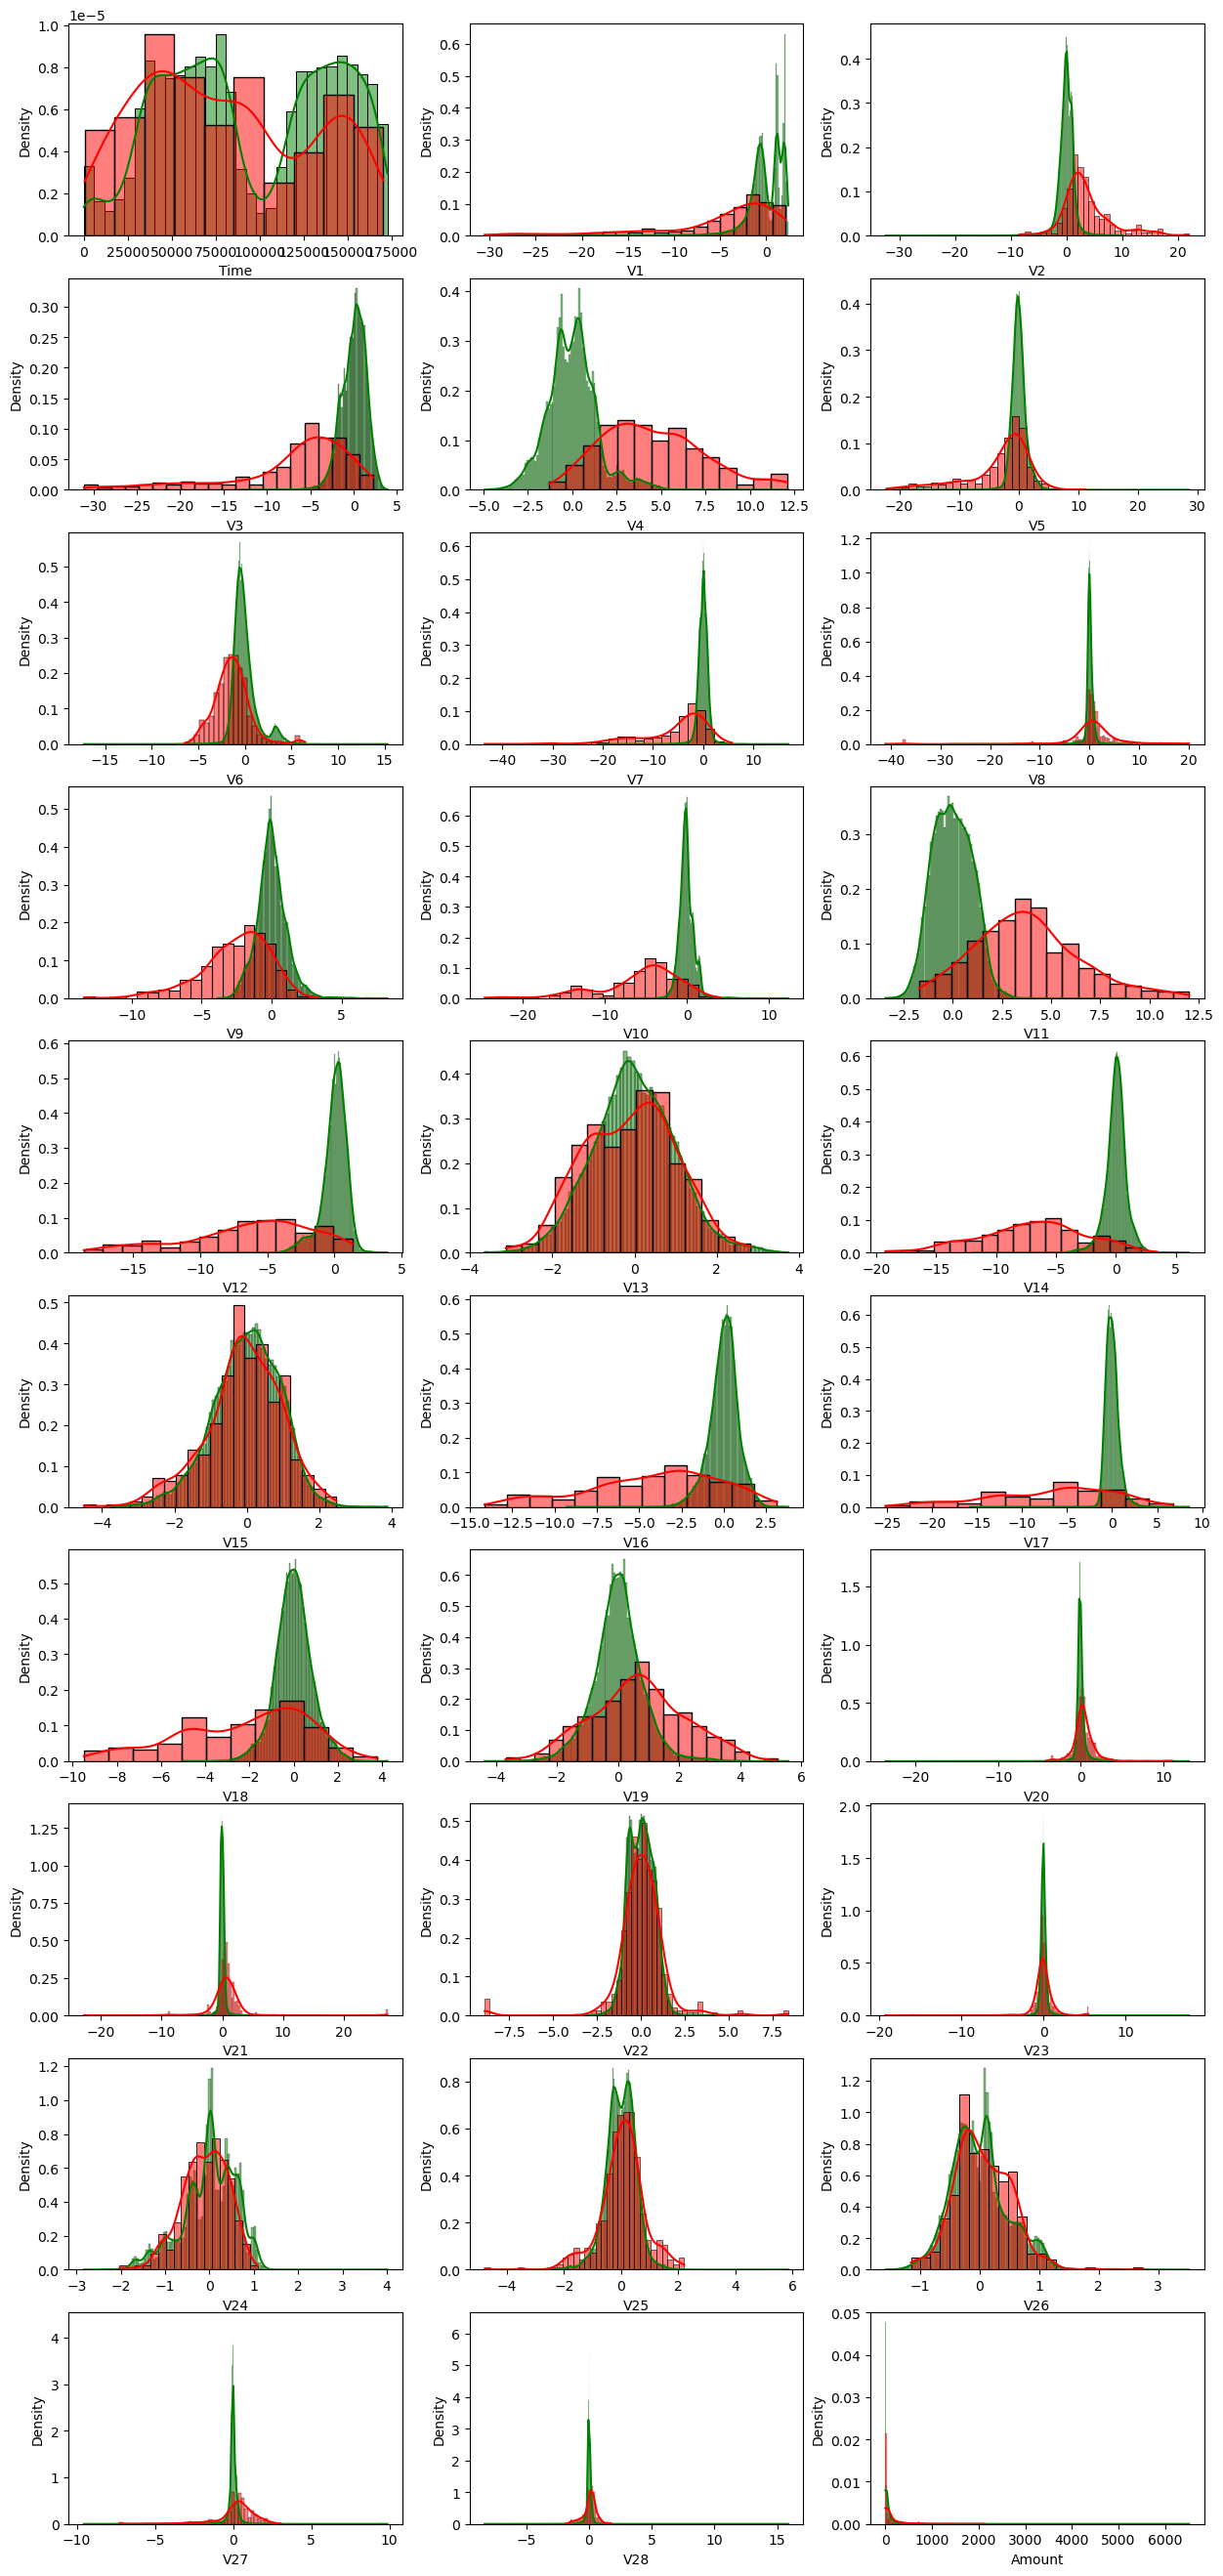

In [1026]:
features = data.drop(columns='Class', errors='ignore' ).columns

fig = plt.figure(figsize=(15, 40))

for i, column in enumerate(features):    
    plt.subplot(12, 3, i+1)
    sns.histplot(data=data_auth, x=column, kde=True, stat='density', color='green')
    sns.histplot(data=data_fraud, x=column, kde=True, stat='density', color='red')
           
plt.show()

We will select only those features that are clearly different in these two classes.

In [1027]:
selected_features = ['V2','V3','V4','V7','V9','V10','V11','V12','V14','V16','V17']
X = pd.concat([data_auth, data_fraud], axis=0)
X = X[selected_features]
X.shape

(25492, 11)

In [1028]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

km = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels = km.fit_predict(X_sc)
X['Class'] = Class
X['cluster_km'] = labels

cluster_counts = X['cluster_km'].value_counts()
cluster = cluster_counts.idxmin()
cluster_data = X[X['cluster_km'] == cluster]
X['cluster_km'].value_counts()

cluster_km
0    25210
1      282
Name: count, dtype: int64

In [1029]:
len(cluster_data.index.intersection(data_fraud.index))

279

In [1030]:
precision = len(cluster_data.index.intersection(data_fraud.index)) / len(cluster_data)
precision

0.9893617021276596

In [1031]:
recal = len(cluster_data.index.intersection(data_fraud.index)) / len(data_fraud)
recal

0.5670731707317073

### Let's test the model on complete and highly unbalanced data

In [1032]:
data_test = data[selected_features]
data.shape

(284807, 31)

In [1033]:
labels = km.predict(data_test)
data_test['labels'] = labels
data_test['Class'] = Class
labels.sum(), len(labels)

(435, 284807)

In [1034]:
precision = len(data_test[data_test['labels']==1].index.intersection(data_test[data_test['Class']==1].index)) / len(data_test[data_test['labels']==1])
precision

0.864367816091954

In [1035]:
recall = len(data_test[data_test['labels']==1].index.intersection(data_test[data_test['Class']==1].index)) / len(data_fraud)
recall

0.7642276422764228